# Apple Stock Prices (1981–2023) — Full Analysis

## 1. Data Loading and Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter

# Load dataset
df = pd.read_csv('Apple_Stock_Prices.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
df['Year'] = df['Date'].dt.year

print('Shape:', df.shape)
print('Date range:', df['Date'].min().date(), '→', df['Date'].max().date())
print('\nNull values:\n', df.isnull().sum())
print('\nData types:\n', df.dtypes)
df.head()

Shape: (10608, 8)
Date range: 1981-01-02 → 2023-01-27

Null values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Year         0
dtype: int64

Data types:
 Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Year                  int32
dtype: object


,Date,Open,High,Low,Close,Adj Close,Volume,Year
0,1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800,1981
1,1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000,1981
2,1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400,1981
3,1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400,1981
4,1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200,1981


In [3]:
# Time series frequency check
gaps = df['Date'].diff().dt.days.dropna()
print('Most common gap between trading days:', gaps.mode()[0], 'day(s)')
print('Total trading days recorded:', len(df))
print('Years covered:', df['Year'].nunique())

Most common gap between trading days: 1.0 day(s)
Total trading days recorded: 10608
Years covered: 43


## 2. Data Visualization

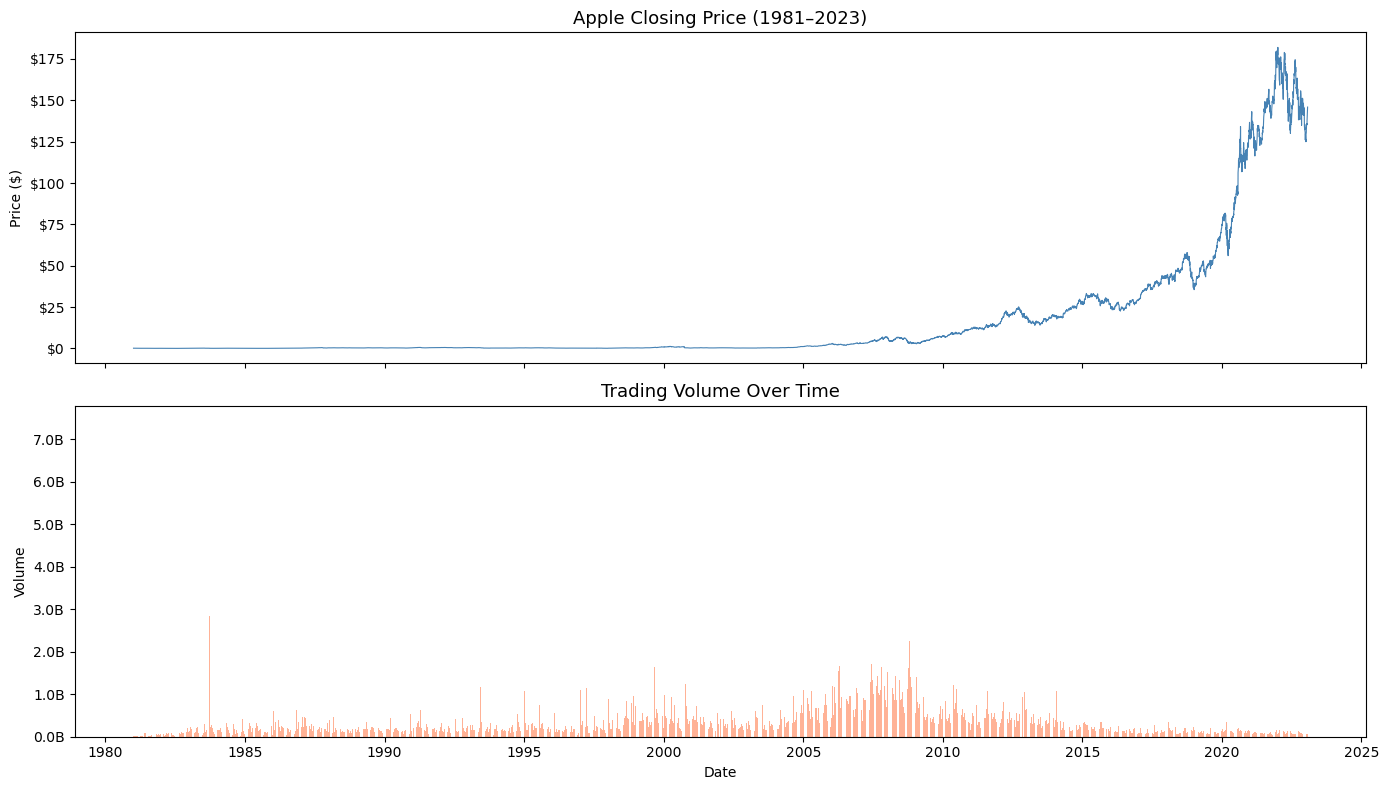

Insight: Price was nearly flat until ~2000, then accelerated exponentially post-iPhone (2007).


In [4]:
# Closing price over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Apple Closing Price (1981–2023)', fontsize=13)
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(df['Date'], df['Volume'], color='coral', alpha=0.6, width=1)
axes[1].set_title('Trading Volume Over Time', fontsize=13)
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.show()
print('Insight: Price was nearly flat until ~2000, then accelerated exponentially post-iPhone (2007).')

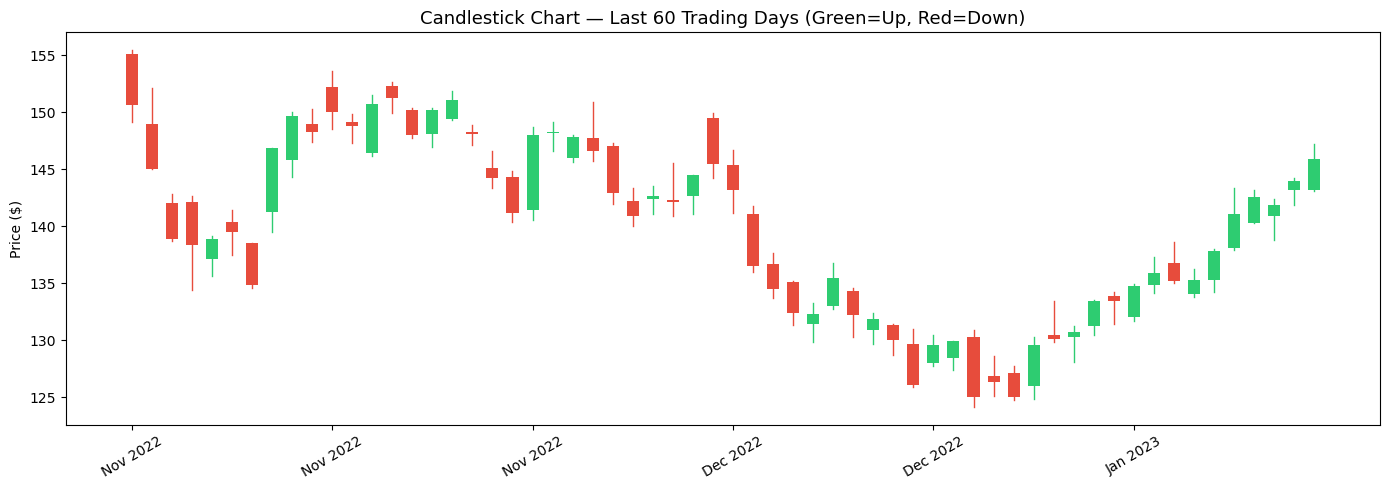

In [5]:
# Candlestick chart — use the last 60 trading days for readability
recent = df.tail(60).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

for i, row in recent.iterrows():
    color = '#2ecc71' if row['Close'] >= row['Open'] else '#e74c3c'
    # High-Low wick
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1)
    # Open-Close body
    ax.bar(i, abs(row['Close'] - row['Open']),
           bottom=min(row['Open'], row['Close']),
           color=color, width=0.6, edgecolor='none')

# X-axis: show every 10th date label
tick_positions = list(range(0, len(recent), 10))
ax.set_xticks(tick_positions)
ax.set_xticklabels([recent['Date'].iloc[i].strftime('%b %Y') for i in tick_positions], rotation=30)
ax.set_title('Candlestick Chart — Last 60 Trading Days (Green=Up, Red=Down)', fontsize=13)
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

## 3. Statistical Analysis

In [6]:
print('=== Summary Statistics ===')
print(df[['Open','High','Low','Close','Volume']].describe().round(2))

print('\n=== Close Price ===')
print(f'Mean   : ${df["Close"].mean():.2f}')
print(f'Median : ${df["Close"].median():.2f}')
print(f'Std Dev: ${df["Close"].std():.2f}')

=== Summary Statistics ===
           Open      High       Low     Close        Volume
count  10608.00  10608.00  10608.00  10608.00  1.060800e+04
mean      16.69     16.88     16.50     16.70  3.275098e+08
std       35.45     35.88     35.03     35.47  3.378203e+08
min        0.05      0.05      0.05      0.05  0.000000e+00
25%        0.29      0.30      0.28      0.29  1.213044e+08
50%        0.49      0.50      0.48      0.49  2.145976e+08
75%       16.32     16.42     16.15     16.27  4.066804e+08
max      182.63    182.94    179.12    182.01  7.421641e+09

=== Close Price ===
Mean   : $16.70
Median : $0.49
Std Dev: $35.47


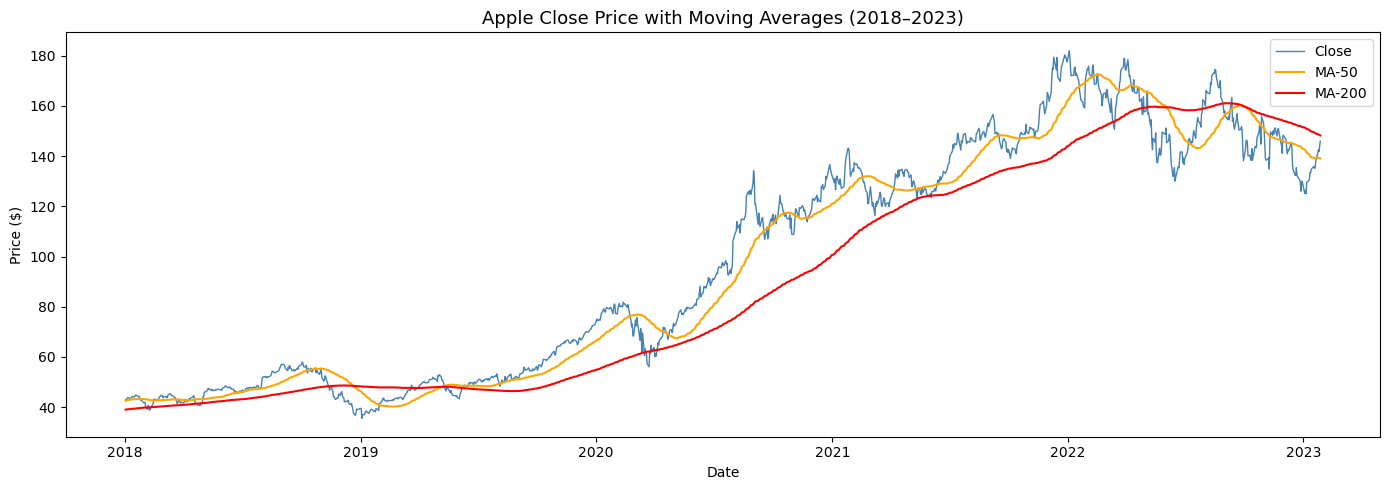

Insight: When MA-50 crosses above MA-200 (Golden Cross), it signals a bullish trend.


In [7]:
# Moving averages: 50-day and 200-day
df['MA50']  = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

# Plot last 5 years for clarity
recent5 = df[df['Year'] >= 2018]

plt.figure(figsize=(14, 5))
plt.plot(recent5['Date'], recent5['Close'],  label='Close',   color='steelblue', linewidth=1)
plt.plot(recent5['Date'], recent5['MA50'],   label='MA-50',   color='orange',    linewidth=1.5)
plt.plot(recent5['Date'], recent5['MA200'],  label='MA-200',  color='red',       linewidth=1.5)
plt.title('Apple Close Price with Moving Averages (2018–2023)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()
print('Insight: When MA-50 crosses above MA-200 (Golden Cross), it signals a bullish trend.')

## 4. Hypothesis Testing

In [8]:
# T-test: average closing price 2010 vs 2020
y2010 = df[df['Year'] == 2010]['Close']
y2020 = df[df['Year'] == 2020]['Close']

t_stat, p_value = stats.ttest_ind(y2010, y2020, equal_var=False)

print('=== T-Test: Closing Price 2010 vs 2020 ===')
print(f'Mean 2010 : ${y2010.mean():.2f}')
print(f'Mean 2020 : ${y2020.mean():.2f}')
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value    : {p_value:.6f}')
if p_value < 0.05:
    print('→ Statistically significant difference (p < 0.05). The means are NOT equal.')
else:
    print('→ No significant difference.')

=== T-Test: Closing Price 2010 vs 2020 ===
Mean 2010 : $9.28
Mean 2020 : $95.35
T-statistic: -62.650
P-value    : 0.000000
→ Statistically significant difference (p < 0.05). The means are NOT equal.


=== Normality Test (Shapiro-Wilk on 500-sample) ===
Statistic: 0.9821
P-value  : 0.000008
→ Daily returns are NOT normally distributed (fat tails — typical for stocks).


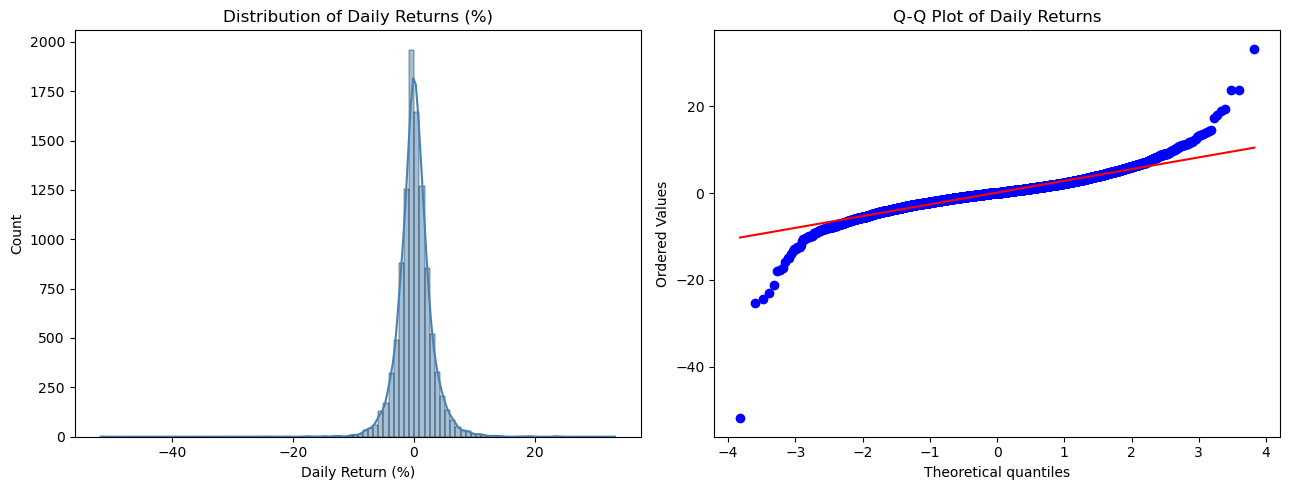

In [9]:
# Daily returns & normality test
df['Daily_Return'] = df['Close'].pct_change() * 100
returns = df['Daily_Return'].dropna()

# Shapiro-Wilk on a sample (full dataset too large for Shapiro)
sample = returns.sample(500, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)

print('=== Normality Test (Shapiro-Wilk on 500-sample) ===')
print(f'Statistic: {shapiro_stat:.4f}')
print(f'P-value  : {shapiro_p:.6f}')
if shapiro_p < 0.05:
    print('→ Daily returns are NOT normally distributed (fat tails — typical for stocks).')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(returns, bins=100, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Daily Returns (%)')
axes[0].set_xlabel('Daily Return (%)')

stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')

plt.tight_layout()
plt.show()

## 5. Advanced Statistical Techniques (Bonus)

### Signal Processing with SciPy

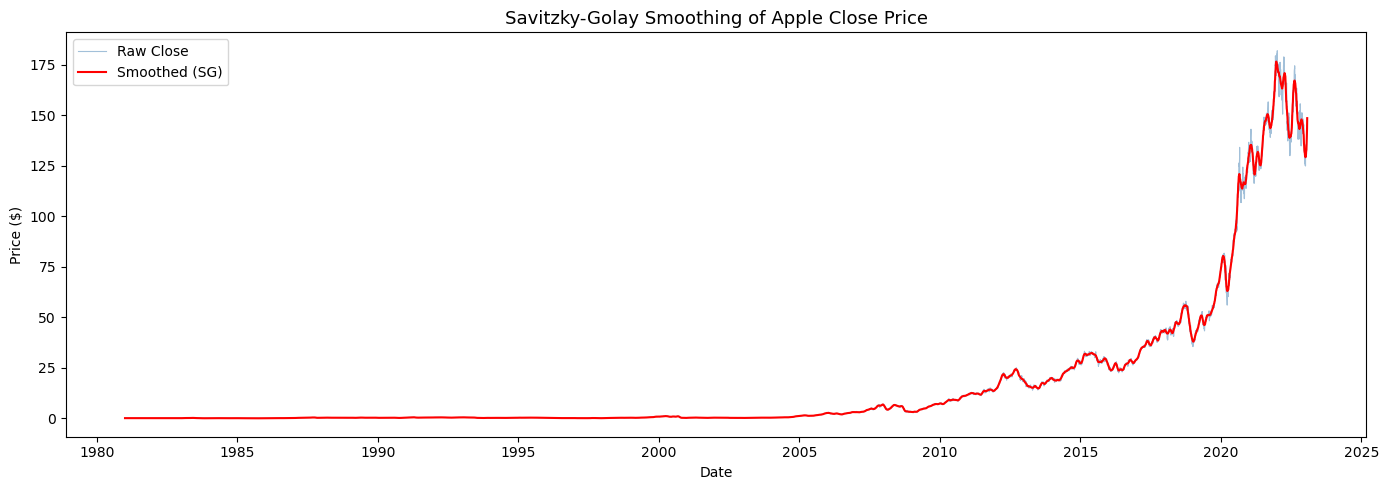

Insight: The SG filter removes daily noise while preserving long-term price trends.


In [10]:
# Savitzky-Golay filter — smooths the price curve while preserving shape
close = df['Close'].values
smoothed = savgol_filter(close, window_length=51, polyorder=3)

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], close,    label='Raw Close',     color='steelblue', alpha=0.5, linewidth=0.8)
plt.plot(df['Date'], smoothed, label='Smoothed (SG)', color='red',       linewidth=1.5)
plt.title('Savitzky-Golay Smoothing of Apple Close Price', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()
print('Insight: The SG filter removes daily noise while preserving long-term price trends.')

### Statistical Functions with NumPy

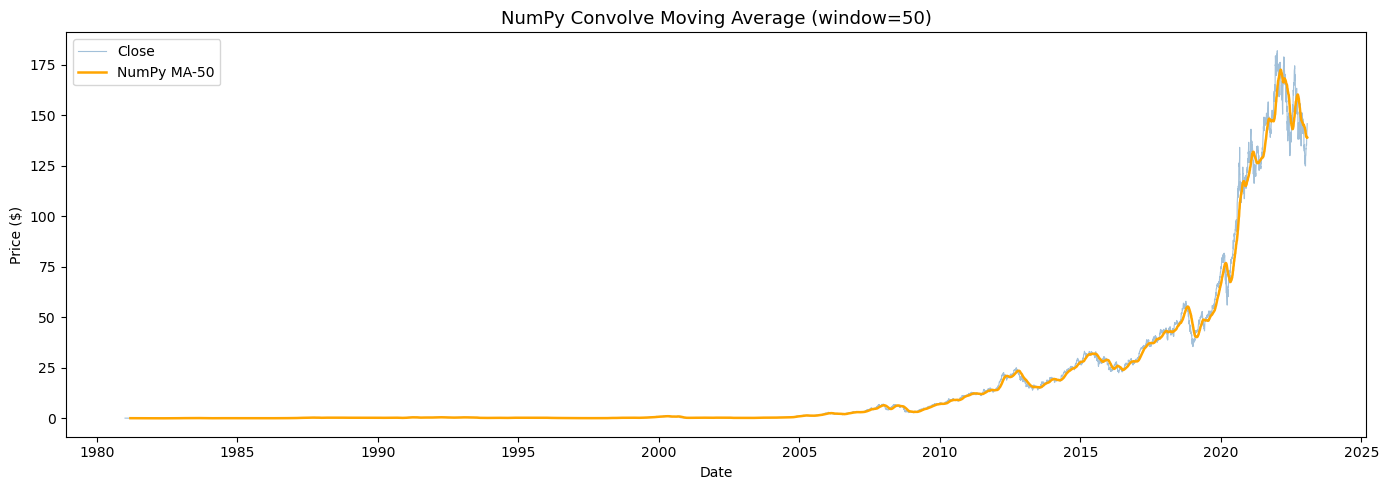

In [11]:
# NumPy convolve for moving average (equivalent to rolling mean)
window = 50
kernel = np.ones(window) / window
ma_numpy = np.convolve(close, kernel, mode='valid')

# Align dates
dates_aligned = df['Date'].iloc[window - 1:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], close, label='Close', color='steelblue', alpha=0.5, linewidth=0.8)
plt.plot(dates_aligned, ma_numpy, label=f'NumPy MA-{window}', color='orange', linewidth=1.8)
plt.title(f'NumPy Convolve Moving Average (window={window})', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

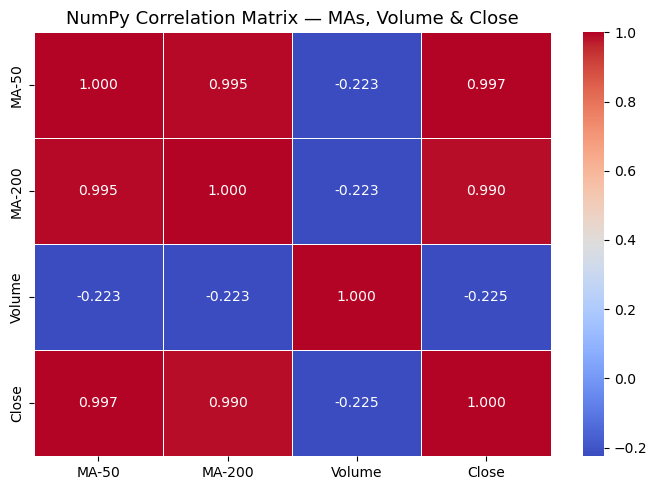

Insight: MA-50 and MA-200 are nearly perfectly correlated with Close price.
Volume shows a slight negative correlation — high volume often accompanies sell-offs.


In [12]:
# Correlation between MA-50, MA-200, and Volume
df_corr = df[['MA50', 'MA200', 'Volume', 'Close']].dropna()

corr_matrix = np.corrcoef([
    df_corr['MA50'].values,
    df_corr['MA200'].values,
    df_corr['Volume'].values,
    df_corr['Close'].values
])

labels = ['MA-50', 'MA-200', 'Volume', 'Close']
corr_df = pd.DataFrame(corr_matrix, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('NumPy Correlation Matrix — MAs, Volume & Close', fontsize=13)
plt.tight_layout()
plt.show()

print('Insight: MA-50 and MA-200 are nearly perfectly correlated with Close price.')
print('Volume shows a slight negative correlation — high volume often accompanies sell-offs.')

## 6. Summary and Insights

**Price growth:** Apple's stock price grew from below $1 in 1981 to over $180 by 2023 — a ~18,000% increase, driven by the iPod era (2001), iPhone launch (2007), and the services/ecosystem pivot (2015+).

**Volume:** Trading volume peaked around 2000–2003 (dot-com boom/bust) and again during high-volatility periods. Long-term volume has trended downward as the stock price rose (fewer shares traded per dollar).

**Moving averages:** The 50-day MA crossing above the 200-day MA (Golden Cross) has historically preceded strong rallies. The reverse (Death Cross) has preceded corrections.

**Daily returns:** NOT normally distributed — the distribution has fat tails (leptokurtic), confirmed by Shapiro-Wilk. This is standard for financial assets and means extreme daily moves happen more often than a normal distribution would predict.

**T-test:** Closing prices in 2010 vs 2020 are statistically significantly different (expected — stock grew ~20x in that period).

**Correlation:** MA-50 and MA-200 track Close price almost perfectly (r ≈ 1.0). Volume is weakly negatively correlated with price, suggesting institutional selling during peaks.

## 7. Reflection

**Challenge 1 — Date parsing:** The dates were in `DD/MM/YYYY` format, not the US default. Using `dayfirst=True` in `pd.to_datetime()` resolved misclassified months.

**Challenge 2 — Candlestick chart:** Matplotlib has no built-in candlestick — we built it manually using `bar()` for bodies and `plot()` for wicks. For production use, `mplfinance` is a cleaner option.

**Challenge 3 — Shapiro-Wilk limit:** Shapiro-Wilk is only reliable on samples under ~5,000. With 10,000+ rows, we sampled 500 points randomly. An alternative for larger datasets is the D'Agostino-Pearson test (`scipy.stats.normaltest`).

**Challenge 4 — NumPy convolve alignment:** `np.convolve` with `mode='valid'` returns a shorter array than the input. We aligned the date index by offsetting by `window - 1` rows.

**Key learning:** Raw close prices are dominated by long-term trend, making most correlations appear high. For real financial analysis, working with **returns** (pct_change) rather than raw prices is more meaningful.